6/23/2026

# v1 — Basic Bigram Language Model

This is the first step in building a GPT-style transformer from scratch. We start with the simplest possible language model: a **bigram model**, which predicts the next character using *only* the current character — no context, no attention, just a lookup table.

We'll train it character-by-character on the Harry Potter text.

## 1. Imports

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

- `batch_size`: how many independent sequences we process in parallel
- `block_size`: the maximum context length used for predictions
- `device`: train on GPU if available, otherwise CPU

In [4]:
# batch_size = 32      # how many independent sequences will we process in parallel?
# block_size = 8       # what is the maximum context length for predictions?
# max_iters = 10000    # maximum number of iterations for training
# eval_interval = 500  # interval for evaluating the model
# learning_rate = 1e-3 # learning rate for training
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200     # number of iterations for evaluation
# seed = 42            # seed for reproducibility

# torch.manual_seed(seed)

In [5]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDAMPS>CPU); set DataLoader workers accordingly

import os

batch_size = 32      # how many independent sequences will we process in parallel?
block_size = 8       # what is the maximum context length for predictions?
max_iters = 10000    # maximum number of iterations for training
eval_interval = 500  # interval for evaluating the model
learning_rate = 1e-3 # learning rate for training
eval_iters = 200     # number of iterations for evaluation
seed = 42            # seed for reproducibility

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

We'll train on the Harry Potter text.

In [6]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


*Roughly 6 million characters make up the dataset*

*We are, in this version, going to use a simple bigram model to do the tokenization*

*And we will predict character by character*

## 4. Tokenization: characters as tokens

The simplest possible tokenizer: every unique character in the text becomes a token. `vocab_size` is just the number of distinct characters.

In [7]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


*71 unique characters*

Now build two lookup tables — `stoi` (string to integer) and `itos` (integer to string) — to convert between characters and integer ids.

*this is the most naive type of tokenizer*

In [8]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

Encode the entire dataset into a tensor of integers, then hold out the last 10% as a validation set.

In [9]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

We never feed the whole dataset to the model at once. Instead we sample random chunks of length `block_size`. For each chunk `x`, the target `y` is the same chunk shifted one character to the right — i.e. "predict the next character at every position".

**In class:** fill in the `TODO`s below.

In [10]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data

    # TODO: sample `batch_size` random starting indices into `data`
    # (careful not to run past the end once you slice out block_size characters)
    ix = torch.randint(len(data) - block_size, (batch_size, )) # notice we leave this second part of this last () empty * TODO: CONFIRM WHY / WHAT ITS DOING?
        # recall batch size is how many independent sequences we process in parallel
        # and block size is the maximum context length for predictions

    # TODO: stack the block_size-length chunk starting at each index in ix -> x
    x = torch.stack([data[i : i + block_size] for i in ix])
        # note pytorch acts similarly to how numpy arrays do but in tensor form

    # TODO: stack the same chunks shifted one character to the right -> y (the targets)
    y = torch.stack([data[i + 1: i + block_size + 1] for i in ix])

    x, y = x.to(device), y.to(device)
    return x, y

*x is the token before and y is the next token we are trying to predict*

In [11]:
# take a peek for better understanding
x, y = get_batch('train')
print(x.shape, y.shape)
print(x[0, :], y[0, :])

torch.Size([32, 8]) torch.Size([32, 8])
tensor([54, 60, 57,  0, 52, 54, 59, 47], device='cuda:0') tensor([60, 57,  0, 52, 54, 59, 47, 44], device='cuda:0')


In [12]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([32, 8])
tensor([[43, 54, 62, 58,  0, 47, 40, 43],
        [44,  0, 54, 45,  0, 26, 40, 46],
        [54, 53, 44,  0, 31, 44, 46,  0],
        [58,  0, 64, 44, 58,  0, 62, 44],
        [59,  0, 59, 47, 48, 57, 43,  0],
        [53,  0, 43, 54, 43, 46, 48, 53],
        [54, 57,  0, 40, 46, 40, 48, 53],
        [ 0, 57, 44, 61, 44, 40, 51, 44],
        [50, 57, 44, 62, 59,  0,  2, 32],
        [17,  0,  1, 20, 48, 53, 53, 64],
        [ 0, 60, 58, 44, 43,  0, 59, 54],
        [54, 60, 51, 43,  0, 41, 44,  0],
        [44, 52,  0, 59, 47, 44, 53,  0],
        [ 0, 51, 54, 54, 50, 48, 53, 46],
        [48, 44, 59, 51, 64,  0,  2, 32],
        [47, 54, 57, 53, 44, 43,  0, 58],
        [ 0, 42, 54, 53, 49, 60, 57, 44],
        [44,  0, 62, 44, 53, 59,  0, 41],
        [44,  0, 40, 53, 43,  0, 58, 54],
        [54, 57, 46, 44,  0, 44, 63, 42],
        [57, 44, 40, 59, 47,  0,  2, 31],
        [44, 51,  0, 60, 53, 42, 54, 52],
        [44, 57, 51, 64,  0,  2, 19, 54],
      

## 7. Estimating loss

Loss on a single batch is noisy, so we average over `eval_iters` batches to get a more stable estimate of train/val loss.

In [13]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. The Bigram Language Model

The entire model is a single `nn.Embedding` table of shape `(vocab_size, vocab_size)`. Given a token, it directly looks up the logits for the next token — no attention, no context beyond the current character. This *is* a bigram model.

- `forward`: looks up logits for each token in the input, and (if targets are given) computes cross-entropy loss
- `generate`: autoregressively samples new tokens from the model's predicted distribution

**In class:** fill in the `TODO`s below.

*in this very simple setup, there is no d-dimensional setup since we only want to predict the next character from the current*

In [14]:
# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token should directly read off the logits for the next token
        # TODO: from a lookup table -> use a single nn.Embedding of shape (vocab_size, vocab_size)
            # because we just want a lookup table that takes a character and predicts the next one
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        # TODO: look up the logits for every token in idx -> shape (B,T,C)
            # [batch, block(or is it tokens??), characters]
        logits = self.token_embedding_table(idx) # pass an id to the lookup table so it can predict the next id

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            # TODO: reshape logits to (B*T, C) and targets to (B*T,),
            # then compute the cross-entropy loss between them
            logits = logits.view(B*T, C) # view lets you reshape / "view" a tensor in another format
                # B*T is basically our batch size x block size
                # so now we view B*T*C as B*T times C? (TODO: GET CLARITY ON THIS)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets) # calculating cross entropy between logits and targets

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # because these models are trained to generate the next token, you need to tell them when to stop with max_new_tokens
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # TODO: get the predictions for the current context
            logits, loss = self(idx)

            # TODO: focus only on the last time step -> becomes (B, C)
            logits = logits[:, -1, :]
                # we just want that last axis of block because... TODO fill this comment in better?

            # TODO: apply softmax to turn logits into probabilities
            probs = F.softmax(logits, dim=-1) # in pytorch, you use dim = -1 to access the last value of the first axis(?) TODO correct this?
                # now we have the probs of each character given current context (TODO confirm?)
            
            # TODO: sample the next token index from the probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)

            # TODO: append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
                # torch.cat() concatenates the current/prev and predicted token and then we predict from there (TODO confirm)

        return idx

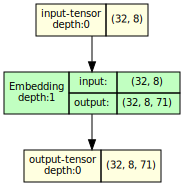

In [16]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

In [17]:
BigramLanguageModel(vocab_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 71)
)

## 9. Sanity check: untrained generation

Before training, the lookup table is random, so the model should generate gibberish. This gives us a baseline to compare against after training.

In [ ]:
model = BigramLanguageModel(vocab_size)
model = model.to(device) # send your variables (could be input vars, model weights, entire model) to device
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))
# notice that we are decoding! because the model generates indices not characters!

0.005041 M parameters


 cE6G!□B8QIy□lCx2CmSf~n■A‘ZNTccWQsQ■Y6B•3□o7•b6I3tzgdYJ‘5WDOX0XR6GJoQo~vhrwamHvHSi0Xpqmh oOF?D□9□j‘sHb~D□G3M9rcAh3Qc00IHWGlPby■xvhfiMox‘2rgpQXilTZGCG□lt8CYzW~•foLblsiX8bgp8‘4G~BCdiMOcEUdSm4u!avtg5Dgpbx


*above we initialized model and then generated an output as a sanity check, but it hasn't learned anything yet, which is why it generates gibberish*

## 10. Training the model

We use AdamW to update the embedding table so it learns the bigram statistics of the dataset.

In [ ]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.5885, val loss 4.5807
step 500: train loss 4.0335, val loss 4.0116
step 1000: train loss 3.5830, val loss 3.5625
step 1500: train loss 3.2467, val loss 3.2187
step 2000: train loss 3.0010, val loss 2.9734
step 2500: train loss 2.8250, val loss 2.8035
step 3000: train loss 2.7029, val loss 2.6752
step 3500: train loss 2.6077, val loss 2.5942
step 4000: train loss 2.5517, val loss 2.5355
step 4500: train loss 2.5007, val loss 2.4909
step 5000: train loss 2.4826, val loss 2.4609
step 5500: train loss 2.4622, val loss 2.4358
step 6000: train loss 2.4437, val loss 2.4247
step 6500: train loss 2.4188, val loss 2.4099
step 7000: train loss 2.4158, val loss 2.3949
step 7500: train loss 2.4220, val loss 2.4001
step 8000: train loss 2.3998, val loss 2.3987
step 8500: train loss 2.3880, val loss 2.3798
step 9000: train loss 2.3940, val loss 2.3884
step 9500: train loss 2.3933, val loss 2.3706
step 9999: train loss 2.3966, val loss 2.3705


## 11. Generate text from the trained model

The model has now learned which character tends to follow which — let's see what it produces.

In [ ]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=1000)[0].tolist())) 
# notice that we are decoding! because the model generates indices not characters!


##########################################
# Let's generate some Harry Potter text! #
##########################################
 med apllouly .Yoprimildd rellin thot ikllouge m hele .TharAng mer .D■wh tod sitopindilait my ce t rel Flid thakeld .Seanckoupr ored d s mefirnd Haid .ty Han wares cGrIthed Mavaimood rr he andne a metivee ilme d arunoomorarsice f .ZSLSUPrn olered hing Herrmean t teanel who je Had Brmar the t oy shag burree ntthaul aguacat .Hondolet Che whe axatas aiatlid Rory Hary worrmacoulerd d me o uteRounaumersl g wewat loot bedgaleau .Yo irm aninfoo ags s acars yoninokthery bowe tl helly avid acrinol pe ber thattealire llay s nentou .He ce sten waly gis He e ok m Im revind e d w wouspecharedin tooolaid ofedlys furbe plaby woped hat ?don ar osed t ?sofu Habombery !me are bexal Hareno waind t geasag s thibonte d blin s s s tor .Won s ofary as coulow ..Theet formerlsteyple ind I amy .NKTe mismmby EWeve Mronthefole henieaig dily m g t t tsah Hulystotay bupothelf toricoUndg 